<a href="https://colab.research.google.com/github/jasmidd/MSSP6070/blob/main/Assignments/Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
!git clone https://github.com/jasmidd/MSSP6070.git

Cloning into 'MSSP6070'...
remote: Enumerating objects: 206, done.
remote: Counting objects: 100% (49/49), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 206 (delta 26), reused 3 (delta 3), pack-reused 157 (from 2)
Receiving objects: 100% (206/206), 8.01 MiB | 6.36 MiB/s, done.
Resolving deltas: 100% (81/81), done.


In [3]:
df = pd.read_excel('/content/MSSP6070/data/data_academic_performance.xlsx', sheet_name=3)

print(df.shape)
df.head()

(12411, 45)


,COD_S11,GENDER,EDU_FATHER,EDU_MOTHER,OCC_FATHER,OCC_MOTHER,STRATUM,SISBEN,PEOPLE_HOUSE,Unnamed: 9,...,CC_PRO,ENG_PRO,WC_PRO,FEP_PRO,G_SC,PERCENTILE,2ND_DECILE,QUARTILE,SEL,SEL_IHE
0,SB11201210000129,F,Incomplete Professional Education,Complete technique or technology,Technical or professional level employee,Home,Stratum 4,It is not classified by the SISBEN,Three,NaN,...,71,93,79,181,180,91,5,4,2,2
1,SB11201210000137,F,Complete Secundary,Complete professional education,Entrepreneur,Independent professional,Stratum 5,It is not classified by the SISBEN,Three,NaN,...,86,98,78,201,182,92,5,4,4,4
2,SB11201210005154,M,Not sure,Not sure,Independent,Home,Stratum 2,Level 2,Five,NaN,...,18,43,22,113,113,7,1,1,1,1
3,SB11201210007504,F,Not sure,Not sure,Other occupation,Independent,Stratum 2,It is not classified by the SISBEN,Three,NaN,...,76,80,48,137,157,67,4,3,2,2
4,SB11201210007548,M,Complete professional education,Complete professional education,Executive,Home,Stratum 4,It is not classified by the SISBEN,One,NaN,...,98,100,71,189,198,98,5,4,4,2


In [4]:
df.isnull().sum()

,0
COD_S11,0
GENDER,0
EDU_FATHER,0
EDU_MOTHER,0
OCC_FATHER,0
OCC_MOTHER,0
STRATUM,0
SISBEN,0
PEOPLE_HOUSE,0
Unnamed: 9,12411


In [5]:
df = df.drop(columns=["Unnamed: 9"])

In [6]:
df["EDU_FATHER"] = df["EDU_FATHER"].replace("Ninguno", "None")
df["EDU_FATHER"] = df["EDU_FATHER"].replace("Complete Secundary", "Complete secondary")
df["EDU_FATHER"] = df["EDU_FATHER"].replace("Incomplete Secundary", "Incomplete secondary")
df["EDU_FATHER"] = df["EDU_FATHER"].replace("Incomplete Professional Education", "Incomplete professional education")
df["EDU_MOTHER"] = df["EDU_MOTHER"].replace("Ninguno", "None")
df["EDU_MOTHER"] = df["EDU_MOTHER"].replace("Complete Secundary", "Complete secondary")
df["EDU_MOTHER"] = df["EDU_MOTHER"].replace("Incomplete Secundary", "Incomplete secondary")
df["EDU_MOTHER"] = df["EDU_MOTHER"].replace("Incomplete Professional Education", "Incomplete professional education")
df["PEOPLE_HOUSE"] = df["PEOPLE_HOUSE"].replace("Nueve", "Nine")
df["PEOPLE_HOUSE"] = df["PEOPLE_HOUSE"].replace("Once", "Eleven")
df["SISBEN"] = df["SISBEN"].replace(
    "Esta clasificada en otro Level del SISBEN", "Other SISBEN level")

SUMMARY STATISTICS

In [7]:
academic_scores = [
    'MAT_S11',
    'CR_S11',
    'CC_S11',
    'BIO_S11',
    'ENG_S11',
    'QR_PRO',
    'CR_PRO',
    'CC_PRO',
    'ENG_PRO',
    'WC_PRO',
    'G_SC'
]

df[academic_scores].describe()

,MAT_S11,CR_S11,CC_S11,BIO_S11,ENG_S11,QR_PRO,CR_PRO,CC_PRO,ENG_PRO,WC_PRO,G_SC
count,12411.000000,12411.000000,12411.000000,12411.000000,12411.000000,12411.000000,12411.000000,12411.00000,12411.000000,12411.000000,12411.000000
mean,64.320764,60.778422,60.705181,63.950528,61.801064,77.417291,62.199339,59.18677,67.498348,53.703408,162.710499
std,11.873650,10.025876,10.120524,11.156869,14.297777,22.673444,27.666558,28.99184,25.495096,30.001734,23.112479
min,26.000000,24.000000,0.000000,11.000000,26.000000,1.000000,1.000000,1.00000,1.000000,0.000000,37.000000
25%,56.000000,54.000000,54.000000,56.000000,50.000000,65.000000,42.000000,36.00000,51.000000,28.000000,147.000000
50%,64.000000,61.000000,60.000000,64.000000,59.000000,85.000000,67.000000,65.00000,74.000000,56.000000,163.000000
75%,72.000000,67.000000,67.000000,71.000000,72.000000,96.000000,86.000000,85.00000,88.000000,80.000000,179.000000
max,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,247.000000


FATHER EDU

In [8]:
df['EDU_FATHER'].value_counts()

,count
EDU_FATHER,
Complete professional education,3016
Complete secondary,2843
Complete technique or technology,1194
Incomplete secondary,1091
Postgraduate education,1085
Complete primary,824
Incomplete primary,735
Incomplete professional education,425
Not sure,407


In [9]:
df["EDU_FATHER"] = df["EDU_FATHER"].astype("string").str.strip()

father_education = df.groupby("EDU_FATHER")["G_SC"].mean()

print(father_education.index.tolist())

['0', 'Complete primary', 'Complete professional education', 'Complete secondary', 'Complete technique or technology', 'Incomplete primary', 'Incomplete professional education', 'Incomplete secondary', 'Incomplete technical or technological', 'None', 'Not sure', 'Postgraduate education']


In [10]:
education_order = [
    "None",
    "Incomplete primary",
    "Complete primary",
    "Incomplete secondary",
    "Complete secondary",
    "Incomplete technical or technological",
    "Complete technique or technology",
    "Incomplete professional education",
    "Complete professional education",
    "Postgraduate education"
]

father_education.reindex(education_order)

,G_SC
EDU_FATHER,
None,156.634146
Incomplete primary,155.729252
Complete primary,155.195388
Incomplete secondary,156.535289
Complete secondary,158.785790
Incomplete technical or technological,162.101083
Complete technique or technology,164.033501
Incomplete professional education,166.917647
Complete professional education,167.765915


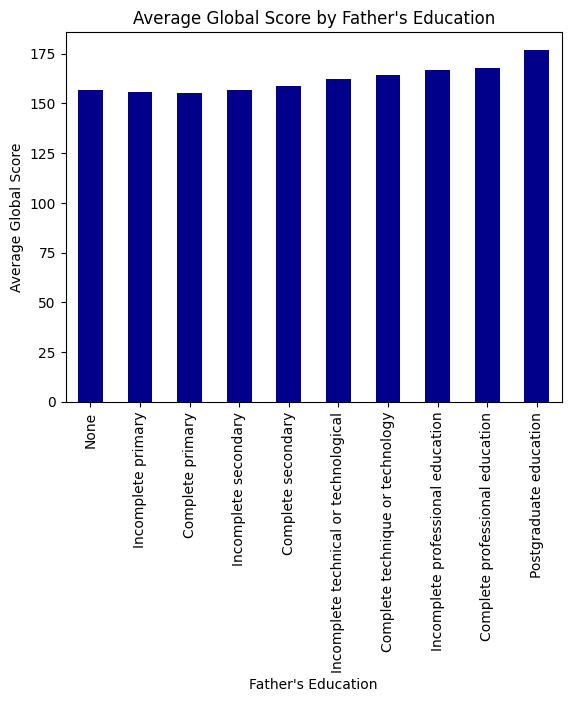

In [11]:
father_means = father_education.reindex(education_order)

father_means.plot(kind='bar', color='darkblue')

plt.title("Average Global Score by Father's Education")
plt.xlabel("Father's Education")
plt.ylabel("Average Global Score")
plt.show()

In [12]:
father_postgrad = df[
    df["EDU_FATHER"] == "Postgraduate education"
]["G_SC"].mean()

father_primary = df[
    df["EDU_FATHER"] == "Complete primary"
]["G_SC"].mean()

father_difference = father_postgrad - father_primary

print("Postgraduate education:", (father_postgrad))
print("Complete primary:", (father_primary))
print("Difference:", (father_difference))

Postgraduate education: 176.9852534562212
Complete primary: 155.19538834951456
Difference: 21.78986510670663


MOTHER EDU

In [13]:
df['EDU_MOTHER'].value_counts()

,count
EDU_MOTHER,
Complete secondary,3106
Complete professional education,3059
Complete technique or technology,1495
Incomplete secondary,1056
Postgraduate education,997
Complete primary,713
Incomplete primary,541
Incomplete professional education,502
0,388


In [14]:
df["EDU_MOTHER"] = df["EDU_MOTHER"].astype("string").str.strip()

mother_education = df.groupby("EDU_MOTHER")["G_SC"].mean()

print(mother_education.index.tolist())

['0', 'Complete primary', 'Complete professional education', 'Complete secondary', 'Complete technique or technology', 'Incomplete primary', 'Incomplete professional education', 'Incomplete secondary', 'Incomplete technical or technological', 'None', 'Not sure', 'Postgraduate education']


In [15]:
mother_education.reindex(education_order)

,G_SC
EDU_MOTHER,
None,149.705882
Incomplete primary,154.853974
Complete primary,155.336606
Incomplete secondary,155.672348
Complete secondary,158.470702
Incomplete technical or technological,161.879765
Complete technique or technology,163.242140
Incomplete professional education,166.685259
Complete professional education,168.845374


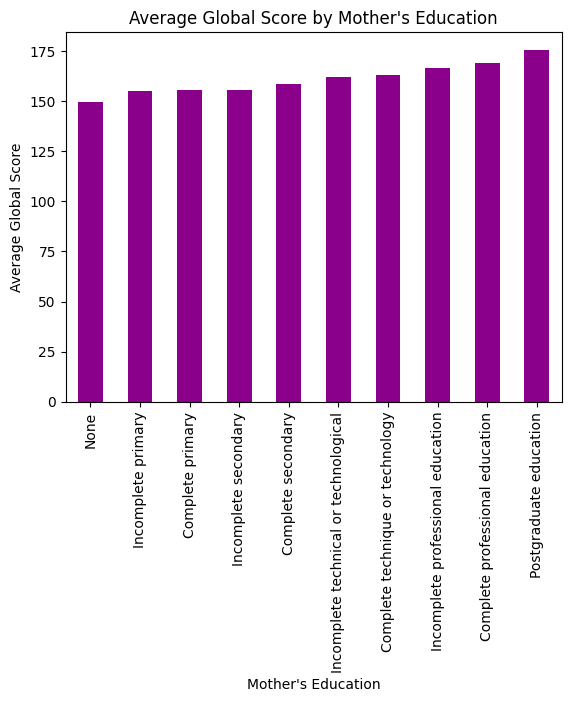

In [16]:
mother_means = mother_education.reindex(education_order)

mother_means.plot(kind='bar', color='darkmagenta')

plt.title("Average Global Score by Mother's Education")
plt.xlabel("Mother's Education")
plt.ylabel("Average Global Score")
plt.show()

In [17]:
mother_postgrad = df[
    df["EDU_MOTHER"] == "Postgraduate education"
]["G_SC"].mean()

mother_primary = df[
    df["EDU_MOTHER"] == "Complete primary"
]["G_SC"].mean()

mother_difference = mother_postgrad - mother_primary

print("Postgraduate education:", (mother_postgrad))
print("Complete primary:", (mother_primary))
print("Difference:", (mother_difference))

Postgraduate education: 175.63691073219658
Complete primary: 155.3366058906031
Difference: 20.300304841593487


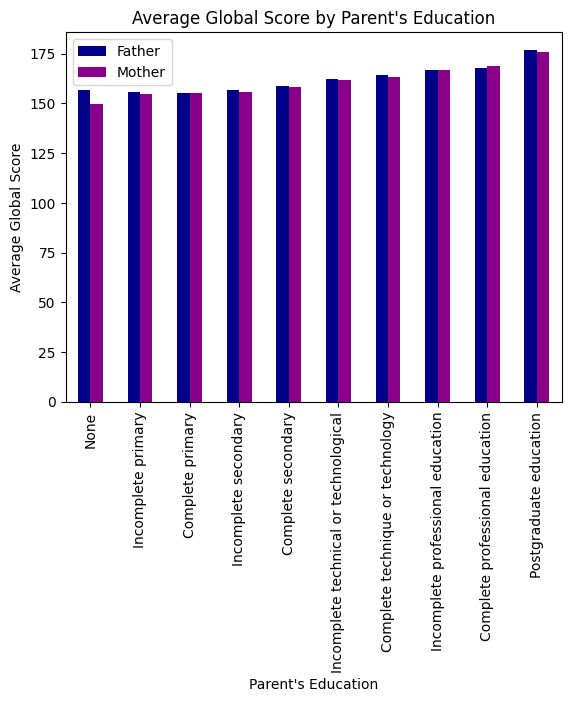

In [18]:
parent_education = pd.DataFrame({
    'Father': father_means,
    'Mother': mother_means
})

parent_education.plot(kind='bar', color=['darkblue', 'darkmagenta'])

plt.title("Average Global Score by Parent's Education")
plt.xlabel("Parent's Education")
plt.ylabel("Average Global Score")
plt.show()

SOCIOECONOMIC STRATUM

In [19]:
stratum_order = [
    "Stratum 1",
    "Stratum 2",
    "Stratum 3",
    "Stratum 4",
    "Stratum 5",
    "Stratum 6"
]

stratum_data = df[df["STRATUM"].isin(stratum_order)]

In [20]:
stratum_summary = (
    stratum_data.groupby("STRATUM")["G_SC"]
    .agg(["count", "mean", "median", "std"])
    .reindex(stratum_order)
)

stratum_summary

,count,mean,median,std
STRATUM,,,,
Stratum 1,1709,152.352838,152.0,21.937401
Stratum 2,4029,158.199305,158.0,22.278029
Stratum 3,4045,163.815328,164.0,21.693970
Stratum 4,1578,172.002535,174.0,21.469094
Stratum 5,633,177.387046,179.0,21.543236
Stratum 6,403,181.511166,184.0,21.879401


In [21]:
stratum_1 = stratum_summary.loc["Stratum 1", "mean"]
stratum_6 = stratum_summary.loc["Stratum 6", "mean"]

stratum_difference = stratum_6 - stratum_1

print("Stratum 1:", stratum_1)
print("Stratum 6:", stratum_6)
print("Difference:", round(stratum_difference, 2))

Stratum 1: 152.3528379169105
Stratum 6: 181.51116625310175
Difference: 29.16


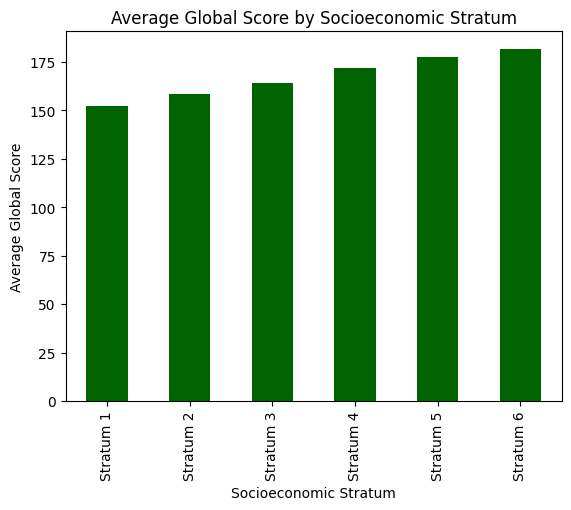

In [22]:
stratum_summary["mean"].plot(kind="bar", color="darkgreen")

plt.title("Average Global Score by Socioeconomic Stratum")
plt.xlabel("Socioeconomic Stratum")
plt.ylabel("Average Global Score")
plt.show()

In [23]:
stratum_competencies = (
    stratum_data.groupby("STRATUM")[academic_scores]
    .mean()
    .reindex(stratum_order)
)

stratum_competencies

,MAT_S11,CR_S11,CC_S11,BIO_S11,ENG_S11,QR_PRO,CR_PRO,CC_PRO,ENG_PRO,WC_PRO,G_SC
STRATUM,,,,,,,,,,,
Stratum 1,59.846694,57.078994,57.267408,60.225863,53.431831,70.520772,53.566413,50.918666,50.911644,49.303686,152.352838
Stratum 2,62.080913,59.121866,59.210722,62.097543,57.214445,74.616282,58.823033,55.956813,60.946389,51.149665,158.199305
Stratum 3,64.339926,61.479852,61.301360,63.956242,62.378245,78.341656,63.857849,60.150062,70.621261,53.043758,163.815328
Stratum 4,69.109632,64.056401,63.577313,67.695817,69.828264,83.215463,69.266160,66.970849,80.097592,59.592522,172.002535
Stratum 5,72.129542,65.492891,64.884676,71.018957,77.022117,86.704581,71.747235,69.230648,87.004739,63.655608,177.387046
Stratum 6,74.667494,66.009926,66.672457,72.665012,82.379653,88.362283,73.764268,71.074442,92.454094,65.585608,181.511166


In [24]:
stratum_competency_gap = (
    stratum_competencies.loc["Stratum 6"]
    - stratum_competencies.loc["Stratum 1"]
)

stratum_competency_gap

,0
MAT_S11,14.820800
CR_S11,8.930932
CC_S11,9.405049
BIO_S11,12.439149
ENG_S11,28.947821
QR_PRO,17.841510
CR_PRO,20.197855
CC_PRO,20.155776
ENG_PRO,41.542450
WC_PRO,16.281922


Text(0, 0.5, 'Score Difference')

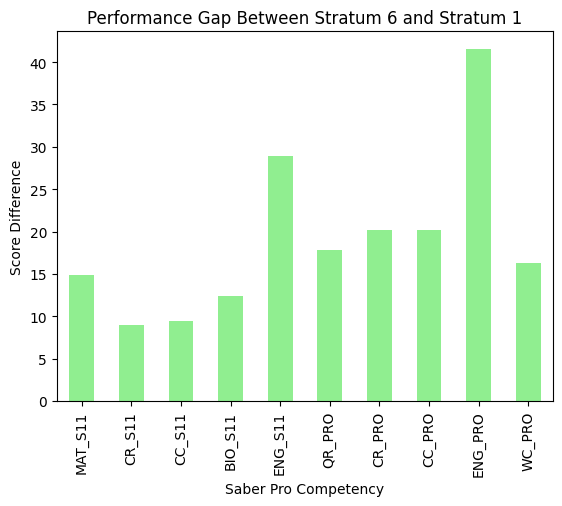

In [25]:
competency_gap_graph = stratum_competency_gap.drop("G_SC")

competency_gap_graph.plot(kind="bar", color="lightgreen")

plt.title("Performance Gap Between Stratum 6 and Stratum 1")
plt.xlabel("Saber Pro Competency")
plt.ylabel("Score Difference")

GENDER

In [26]:
df['GENDER'].value_counts()

,count
GENDER,
M,7368
F,5043


In [27]:
gender_summary = df.groupby('GENDER')['G_SC'].agg(
    ['count', 'mean', 'median', 'std']
)

gender_summary

,count,mean,median,std
GENDER,,,,
F,5043,161.278207,162.0,22.332939
M,7368,163.690825,164.0,23.582616


In [28]:
gender_competencies = (
    df.groupby("GENDER")[academic_scores]
    .mean()
)

gender_competencies

,MAT_S11,CR_S11,CC_S11,BIO_S11,ENG_S11,QR_PRO,CR_PRO,CC_PRO,ENG_PRO,WC_PRO,G_SC
GENDER,,,,,,,,,,,
F,61.932382,60.895300,59.959944,62.268293,61.451120,71.892723,61.338687,58.573865,66.532421,56.618084,161.278207
M,65.955483,60.698426,61.215255,65.101927,62.040581,81.198561,62.788409,59.606270,68.159473,51.708469,163.690825


In [29]:
gender_gap = (
    gender_competencies.loc["M"]
    - gender_competencies.loc["F"]
)

gender_gap

,0
MAT_S11,4.023102
CR_S11,-0.196875
CC_S11,1.255311
BIO_S11,2.833635
ENG_S11,0.589461
QR_PRO,9.305839
CR_PRO,1.449722
CC_PRO,1.032406
ENG_PRO,1.627052
WC_PRO,-4.909615


Text(0, 0.5, 'Average Score')

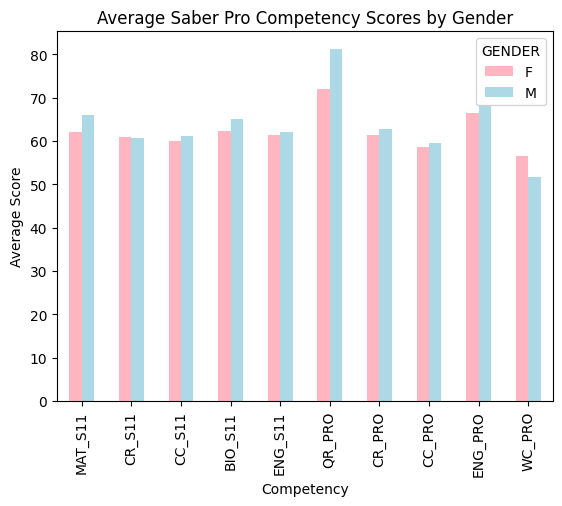

In [30]:
gender_competencies.drop(columns="G_SC").T.plot(
    kind="bar", color=["lightpink", "lightblue"]
)

plt.title("Average Saber Pro Competency Scores by Gender")
plt.xlabel("Competency")
plt.ylabel("Average Score")

PRIOR ACADEMIC PREPARATION

In [31]:
high_school_scores = [
    "MAT_S11",
    "CR_S11",
    "CC_S11",
    "BIO_S11",
    "ENG_S11"
]

prior_performance = (
    df[high_school_scores + ["G_SC"]]
    .corr()["G_SC"]
    .drop("G_SC")
    .sort_values(ascending=True)
)

prior_performance

,G_SC
CC_S11,0.634900
MAT_S11,0.643838
CR_S11,0.653572
ENG_S11,0.662169
BIO_S11,0.666635


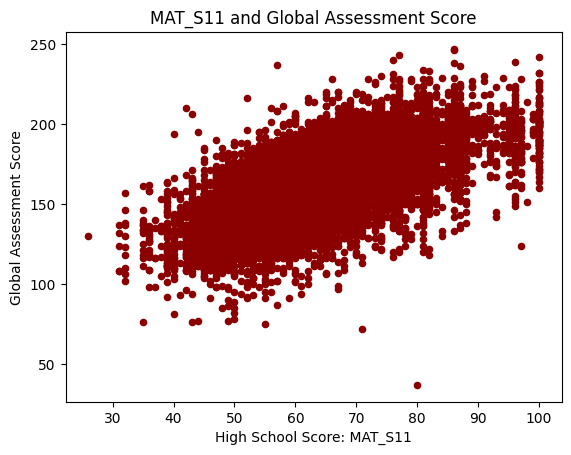

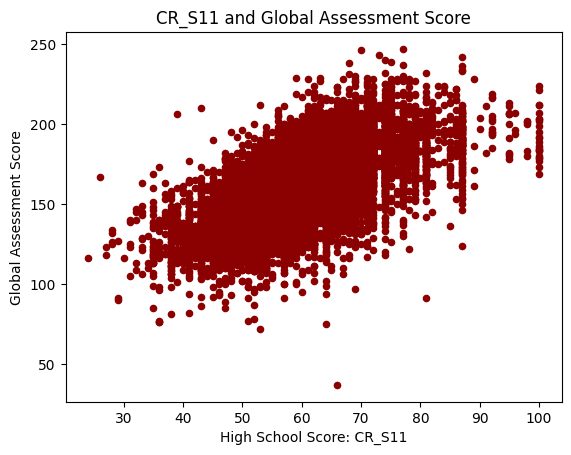

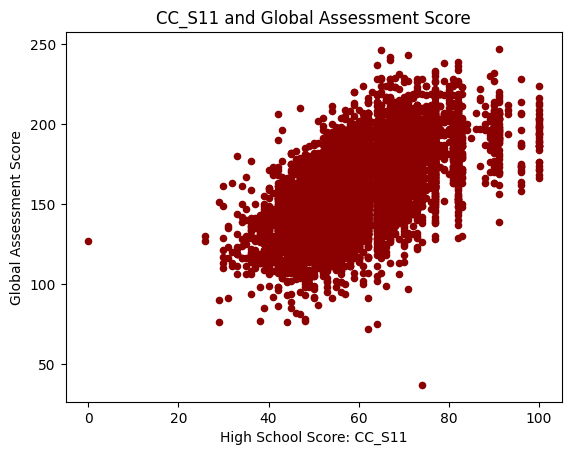

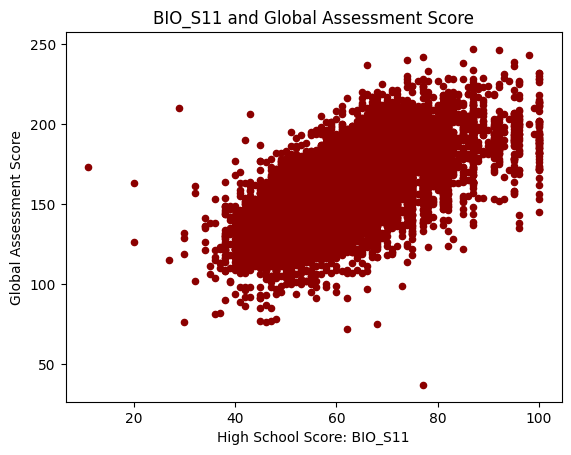

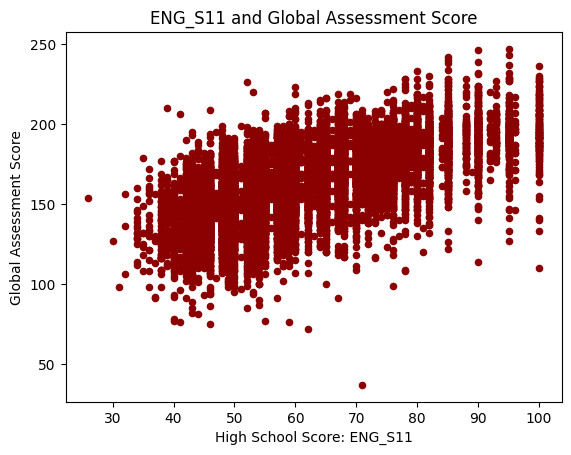

In [32]:
for score in high_school_scores:
    df.plot(
        kind="scatter",
        color="darkred",
        x=score,
        y="G_SC",
    )

    plt.title(f"{score} and Global Assessment Score")
    plt.xlabel(f"High School Score: {score}")
    plt.ylabel("Global Assessment Score")
    plt.show()

ACADEMIC PROGRAMS

In [33]:
program_summary = (
    df.groupby("ACADEMIC_PROGRAM")
    .agg(
        Students=("G_SC", "count"),
        Global_Score=("G_SC", "mean"),
        High_School_Math=("MAT_S11", "mean"),
        High_School_Reading=("CR_S11", "mean"),
        High_School_Biology=("BIO_S11", "mean"),
        University_Quantitative=("QR_PRO", "mean")
    )
)

program_summary_30 = (
    program_summary[
        program_summary["Students"] >= 30
    ]
    .sort_values("Global_Score", ascending=True)
)

program_summary_30

,Students,Global_Score,High_School_Math,High_School_Reading,High_School_Biology,University_Quantitative
ACADEMIC_PROGRAM,,,,,,
ELECTROMECHANICAL ENGINEERING,34,148.617647,61.264706,58.294118,61.000000,73.294118
MECHATRONICS ENGINEERING,82,151.560976,60.500000,54.817073,60.219512,70.231707
AERONAUTICAL ENGINEERING,44,155.795455,59.977273,57.750000,60.181818,74.250000
INDUSTRIAL ENGINEERING,5318,159.042497,61.879090,59.520873,61.630876,72.118466
ELECTRIC ENGINEERING AND TELECOMMUNICATIONS,47,160.425532,62.382979,60.276596,62.914894,74.510638
CIVIL ENGINEERING,3320,161.110542,64.009940,59.849096,63.220181,78.818072
MECHANICAL ENGINEERING,1135,166.051982,67.663436,62.073128,67.065198,82.727753
ELECTRONIC ENGINEERING,849,166.872792,67.889282,62.813899,67.654888,82.143698
TOPOGRAPHIC ENGINEERY,42,172.714286,68.333333,64.142857,67.857143,85.404762


TECHNOLOGY ACCESS

In [34]:
internet_summary = (
    df.groupby("INTERNET")["G_SC"]
    .agg(["count", "mean", "median"])
)

internet_summary

,count,mean,median
INTERNET,,,
No,2659,154.616397,154.0
Yes,9752,164.917453,166.0


In [35]:
computer_summary = (
    df.groupby("COMPUTER")["G_SC"]
    .agg(["count", "mean", "median"])
)

computer_summary

,count,mean,median
COMPUTER,,,
No,2237,155.952615,156.0
Yes,10174,164.196383,165.0


In [36]:
internet_gap = (
    internet_summary.loc["Yes", "mean"]
    - internet_summary.loc["No", "mean"]
)

computer_gap = (
    computer_summary.loc["Yes", "mean"]
    - computer_summary.loc["No", "mean"]
)

print("Internet access difference:", round(internet_gap, 2))
print("Computer access difference:", round(computer_gap, 2))

Internet access difference: 10.3
Computer access difference: 8.24


REVENUE

In [37]:
df['REVENUE'].value_counts()

,count
REVENUE,
Between 1 and less than 2 LMMW,3873
Between 2 and less than 3 LMMW,2783
Between 3 and less than 5 LMMW,2239
less than 1 LMMW,1037
Between 5 and less than 7 LMMW,973
10 or more LMMW,718
Between 7 and less than 10 LMMW,509
0,279


In [38]:
df["REVENUE"] = df["REVENUE"].astype("string").str.strip()

print(df["REVENUE"].unique().tolist())

['Between 1 and less than 2 LMMW', '10 or more LMMW', 'Between 2 and less than 3 LMMW', 'Between 7 and less than 10 LMMW', 'less than 1 LMMW', 'Between 3 and less than 5 LMMW', 'Between 5 and less than 7 LMMW', '0']


In [39]:
revenue_order = [
    "less than 1 LMMW",
    "Between 1 and less than 2 LMMW",
    "Between 2 and less than 3 LMMW",
    "Between 3 and less than 5 LMMW",
    "Between 5 and less than 7 LMMW",
    "Between 7 and less than 10 LMMW",
    "10 or more LMMW"
]

revenue_data = df[df["REVENUE"].isin(revenue_order)]

In [40]:
revenue_program_results = (
    revenue_data.groupby(["ACADEMIC_PROGRAM", "REVENUE"])["G_SC"]
    .agg(["count", "mean", "median"])
)

print(revenue_program_results)

                                                                    count  \
ACADEMIC_PROGRAM                    REVENUE                                 
AERONAUTICAL ENGINEERING            10 or more LMMW                     1   
                                    Between 1 and less than 2 LMMW     11   
                                    Between 2 and less than 3 LMMW     19   
                                    Between 3 and less than 5 LMMW      8   
                                    Between 5 and less than 7 LMMW      2   
...                                                                   ...   
TOPOGRAPHIC ENGINEERY               less than 1 LMMW                    4   
TRANSPORTATION AND ROAD ENGINEERING Between 1 and less than 2 LMMW     11   
                                    Between 2 and less than 3 LMMW      4   
                                    Between 3 and less than 5 LMMW      1   
                                    less than 1 LMMW                   11   

In [41]:
revenue_counts = pd.crosstab(
    df["ACADEMIC_PROGRAM"],
    df["REVENUE"].astype("string").str.strip()
)

revenue_counts = revenue_counts.reindex(
    columns=revenue_order,
    fill_value=0
)

revenue_percentages = (
    revenue_counts.div(revenue_counts.sum(axis=1), axis=0) * 100
)

revenue_table = revenue_percentages
display(revenue_table)

REVENUE,less than 1 LMMW,Between 1 and less than 2 LMMW,Between 2 and less than 3 LMMW,Between 3 and less than 5 LMMW,Between 5 and less than 7 LMMW,Between 7 and less than 10 LMMW,10 or more LMMW
ACADEMIC_PROGRAM,,,,,,,
AERONAUTICAL ENGINEERING,6.818182,25.000000,43.181818,18.181818,4.545455,0.000000,2.272727
AUTOMATION ENGINEERING,0.000000,30.000000,20.000000,40.000000,0.000000,0.000000,10.000000
CATASTRAL ENGINEERING AND GEODESY,3.846154,43.589744,25.641026,21.794872,2.564103,2.564103,0.000000
CHEMICAL ENGINEERING,4.352332,25.492228,22.901554,21.554404,12.435233,5.284974,7.979275
CIVIL CONSTRUCTIONS,0.000000,64.285714,28.571429,0.000000,0.000000,7.142857,0.000000
CIVIL ENGINEERING,7.647240,32.346593,23.280913,19.118101,8.572310,3.854456,5.180389
CONTROL ENGINEERING,5.000000,45.000000,30.000000,15.000000,5.000000,0.000000,0.000000
ELECTRIC ENGINEERING,8.791209,33.699634,26.739927,16.849817,5.494505,4.395604,4.029304
ELECTRIC ENGINEERING AND TELECOMMUNICATIONS,0.000000,32.608696,23.913043,28.260870,10.869565,2.173913,2.173913


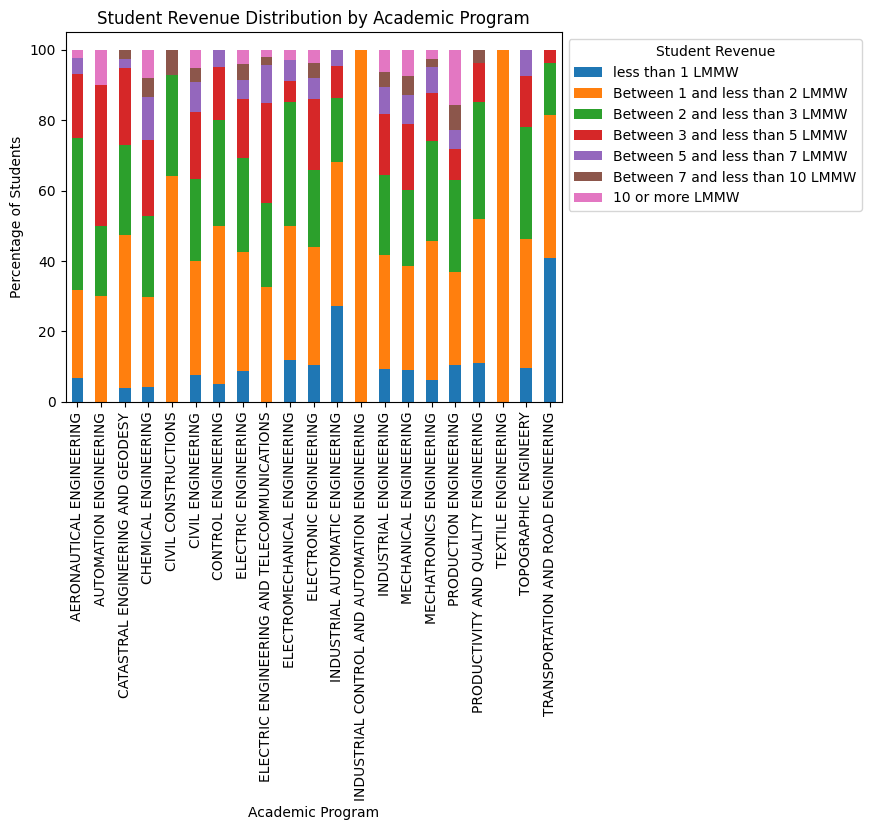

In [42]:
revenue_percentages.plot(kind="bar", stacked=True)

plt.title("Student Revenue Distribution by Academic Program")
plt.xlabel("Academic Program")
plt.ylabel("Percentage of Students")
plt.legend(
    title="Student Revenue",
    bbox_to_anchor=(1, 1),
    loc="upper left")
plt.show()

In [43]:
revenue_performance = (
    df[df["REVENUE"].isin(revenue_order)]
    .groupby("REVENUE")["G_SC"]
    .agg(["count", "mean", "median"])
    .reindex(revenue_order)
)

display(revenue_performance)

,count,mean,median
REVENUE,,,
less than 1 LMMW,1037,153.314368,153.0
Between 1 and less than 2 LMMW,3873,156.770462,157.0
Between 2 and less than 3 LMMW,2783,160.942867,162.0
Between 3 and less than 5 LMMW,2239,165.336311,167.0
Between 5 and less than 7 LMMW,973,170.860226,172.0
Between 7 and less than 10 LMMW,509,176.176817,178.0
10 or more LMMW,718,183.672702,185.0


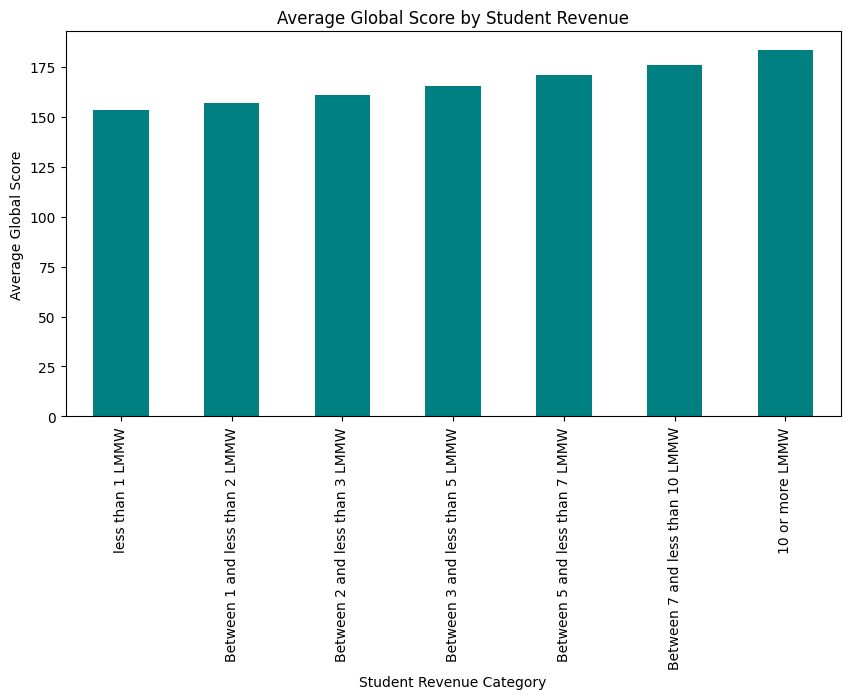

In [44]:
revenue_performance["mean"].plot(
    kind="bar",
    figsize=(10, 5),
    color="teal"
)

plt.title("Average Global Score by Student Revenue")
plt.xlabel("Student Revenue Category")
plt.ylabel("Average Global Score")
plt.show()

In [45]:
revenue_gap = (
    revenue_performance.loc["10 or more LMMW", "mean"]
    - revenue_performance.loc["less than 1 LMMW", "mean"]
)

print(
    "Global score difference (highest minus lowest revenue):",
    (revenue_gap), "points"
)

Global score difference (highest minus lowest revenue): 30.358333579561787 points


CONCLUSION

In [46]:
print("SUMMARY OF KEY FINDINGS")

print("\nOVERALL ACADEMIC PERFORMANCE")
print("Average global score:", (df["G_SC"].mean()))
print("Median global score:", (df["G_SC"].median()))

print("\nFATHER'S EDUCATION")
display(df.groupby("EDU_FATHER")["G_SC"].agg(
    ["count", "mean", "median"]
))
print(
    "Postgraduate minus complete primary:",
    (father_difference), "points")

print("\nMOTHER'S EDUCATION")
display(df.groupby("EDU_MOTHER")["G_SC"].agg(
    ["count", "mean", "median"]
))
print("Postgraduate minus complete primary:",
      (mother_difference), "points")

print("\nSOCIOECONOMIC STRATUM")
display(stratum_summary)
print("Stratum 6 miunus stratum 1:",
      (stratum_difference), "points")

print("\nGENDER")
print("Gener averages by competency:", (gender_competencies))
print("Difference (male minus female):",
      (gender_gap), "points")

print("\nHIGH SCHOOL SCORES AND GLOBAL PERFORMANCE")
display(prior_performance)

print("\nSTUDENT REVENUE AND ACADEMIC PERFORMANCE")
display(revenue_performance)
print("Difference (highest minus lowest revenue):",
      (revenue_gap), "points")

print("\nSTUDENT REVENUE DISTRIBUTION BY PROGRAM (%)")
display(revenue_percentages)

SUMMARY OF KEY FINDINGS

OVERALL ACADEMIC PERFORMANCE
Average global score: 162.71049875110788
Median global score: 163.0

FATHER'S EDUCATION


,count,mean,median
EDU_FATHER,,,
0,391,155.076726,155.0
Complete primary,824,155.195388,155.0
Complete professional education,3016,167.765915,169.0
Complete secondary,2843,158.785790,159.0
Complete technique or technology,1194,164.033501,164.0
Incomplete primary,735,155.729252,156.0
Incomplete professional education,425,166.917647,168.0
Incomplete secondary,1091,156.535289,157.0
Incomplete technical or technological,277,162.101083,162.0


Postgraduate minus complete primary: 21.78986510670663 points

MOTHER'S EDUCATION


,count,mean,median
EDU_MOTHER,,,
0,388,154.930412,155.0
Complete primary,713,155.336606,155.0
Complete professional education,3059,168.845374,170.0
Complete secondary,3106,158.470702,159.0
Complete technique or technology,1495,163.242140,163.0
Incomplete primary,541,154.853974,155.0
Incomplete professional education,502,166.685259,168.0
Incomplete secondary,1056,155.672348,156.0
Incomplete technical or technological,341,161.879765,164.0


Postgraduate minus complete primary: 20.300304841593487 points

SOCIOECONOMIC STRATUM


...

,G_SC
CC_S11,0.634900
MAT_S11,0.643838
CR_S11,0.653572
ENG_S11,0.662169
BIO_S11,0.666635



STUDENT REVENUE AND ACADEMIC PERFORMANCE


,count,mean,median
REVENUE,,,
less than 1 LMMW,1037,153.314368,153.0
Between 1 and less than 2 LMMW,3873,156.770462,157.0
Between 2 and less than 3 LMMW,2783,160.942867,162.0
Between 3 and less than 5 LMMW,2239,165.336311,167.0
Between 5 and less than 7 LMMW,973,170.860226,172.0
Between 7 and less than 10 LMMW,509,176.176817,178.0
10 or more LMMW,718,183.672702,185.0


Difference (highest minus lowest revenue): 30.358333579561787 points

STUDENT REVENUE DISTRIBUTION BY PROGRAM (%)


REVENUE,less than 1 LMMW,Between 1 and less than 2 LMMW,Between 2 and less than 3 LMMW,Between 3 and less than 5 LMMW,Between 5 and less than 7 LMMW,Between 7 and less than 10 LMMW,10 or more LMMW
ACADEMIC_PROGRAM,,,,,,,
AERONAUTICAL ENGINEERING,6.818182,25.000000,43.181818,18.181818,4.545455,0.000000,2.272727
AUTOMATION ENGINEERING,0.000000,30.000000,20.000000,40.000000,0.000000,0.000000,10.000000
CATASTRAL ENGINEERING AND GEODESY,3.846154,43.589744,25.641026,21.794872,2.564103,2.564103,0.000000
CHEMICAL ENGINEERING,4.352332,25.492228,22.901554,21.554404,12.435233,5.284974,7.979275
CIVIL CONSTRUCTIONS,0.000000,64.285714,28.571429,0.000000,0.000000,7.142857,0.000000
CIVIL ENGINEERING,7.647240,32.346593,23.280913,19.118101,8.572310,3.854456,5.180389
CONTROL ENGINEERING,5.000000,45.000000,30.000000,15.000000,5.000000,0.000000,0.000000
ELECTRIC ENGINEERING,8.791209,33.699634,26.739927,16.849817,5.494505,4.395604,4.029304
ELECTRIC ENGINEERING AND TELECOMMUNICATIONS,0.000000,32.608696,23.913043,28.260870,10.869565,2.173913,2.173913
